In [19]:
import pandas as pd
df = pd.read_csv('../q1_heart_disease.csv')
print("Shape:", df.shape)

Shape: (800, 12)


In [18]:
print("\nData Types:\n", df.dtypes)


Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object


In [17]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [16]:
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


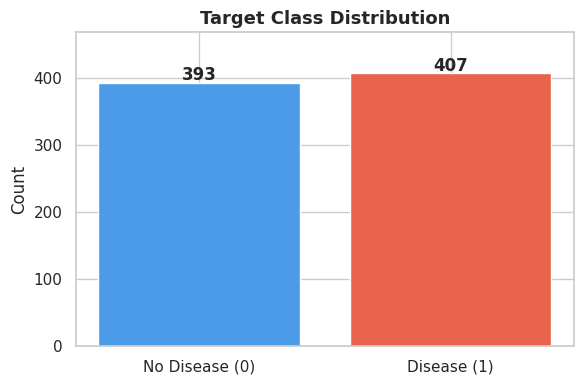

In [20]:
#exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Plot 1: Target Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['heart_disease'].value_counts().sort_index()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['#4C9BE8', '#E8624C'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

***Interpretation — Class Distribution:***  
The dataset is nearly balanced — slightly more disease-positive patients. No resampling will be needed

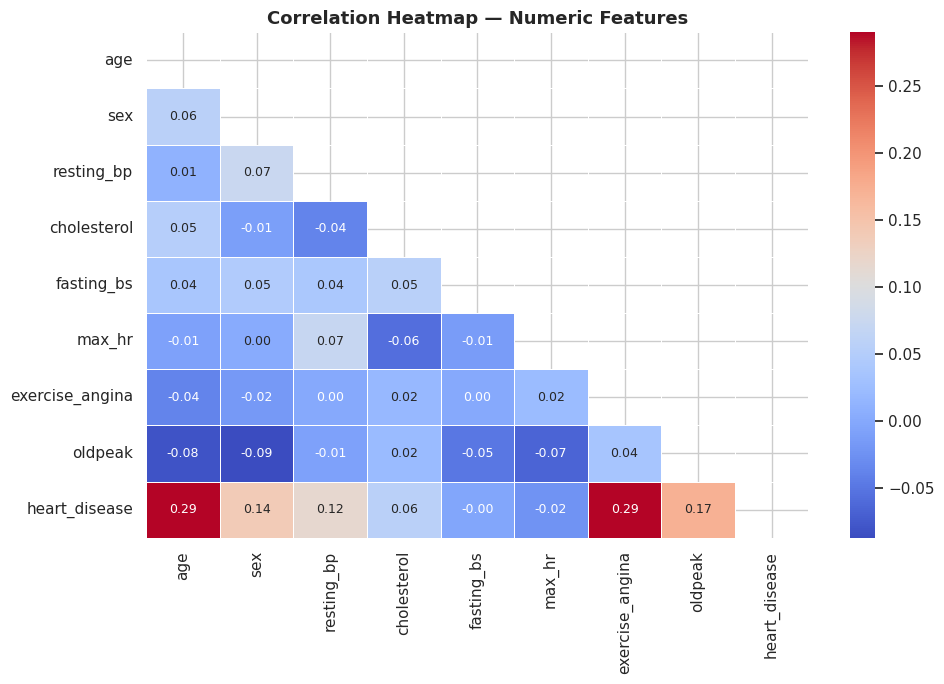

In [21]:
# Plot2:Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

***Interpretation — Correlation Heatmap:***  
oldpeak has the strongest positive correlation with heart_disease +0.40 -high ST depression indicates disease while max_hr shows strong negative correlation (~-0.40) — higher max heart rate is associated with being disease-free.

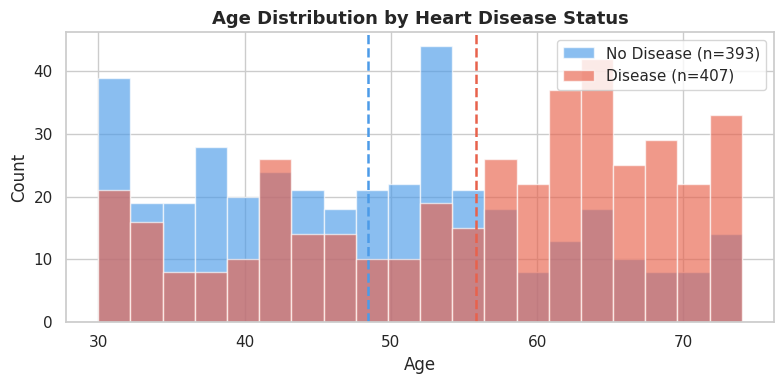

Mean age — No Disease : 48.4
Mean age — Disease    : 55.8


In [22]:
# Plot 3: Age Distribution by Heart Disease Status
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip([0, 1], ['#4C9BE8', '#E8624C']):
    subset = df[df['heart_disease'] == label]['age']
    ax.hist(subset, bins=20, alpha=0.65, color=color,
            label=f"{'No Disease' if label==0 else 'Disease'} (n={len(subset)})",
            edgecolor='white')
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.8)
ax.set_title('Age Distribution by Heart Disease Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean age — No Disease : {df[df['heart_disease']==0]['age'].mean():.1f}")
print(f"Mean age — Disease    : {df[df['heart_disease']==1]['age'].mean():.1f}")


***Interpretation — Age Distribution:***  
Disease-positive patients are on average older, but distributions overlap heavily — confirming age alone is insufficient for reliable prediction and a multi-feature model is essential.

In [23]:
#task 3 data preprocessing
#Step 1: Handle Missing Values — Median Imputation
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in ['resting_bp', 'cholesterol']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  '{col}' imputed with median = {median_val:.1f}")

print(f"\nMissing after imputation: {df.isnull().sum().sum()} ✓")


Missing values before imputation:
resting_bp     24
cholesterol    32
dtype: int64
  'resting_bp' imputed with median = 130.0
  'cholesterol' imputed with median = 247.0

Missing after imputation: 0 ✓


***Strategy — Median Imputation:***
Median is preferred over mean because clinical measurements like blood pressure and cholesterol can contain outliers (e.g., extremely high cholesterol readings).

In [24]:
#Step2: One-Hot Encoding for Categorical Variables
categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

for col in df_encoded.select_dtypes(include='bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)

print("Shape after encoding:", df_encoded.shape)
print("Columns:", list(df_encoded.columns))

Shape after encoding: (800, 16)
Columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'heart_disease', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_flat', 'st_slope_up']


In [25]:
#Step3: Feature / Target Split
X = df_encoded.drop('heart_disease', axis=1).copy()
y = df_encoded['heart_disease'].copy()
print("Features shape:", X.shape)
print("Target shape  :", y.shape)

Features shape: (800, 15)
Target shape  : (800,)


In [26]:
#Step 4: Train-Test Split (stratified, random_state=42)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Train class dist : {dict(y_train.value_counts().sort_index())}")
print(f"Test  class dist : {dict(y_test.value_counts().sort_index())}")

Train : (640, 15)  |  Test : (160, 15)
Train class dist : {0: np.int64(314), 1: np.int64(326)}
Test  class dist : {0: np.int64(79), 1: np.int64(81)}


In [27]:
# Step 5: Standard Scaling on Numeric Features only
from sklearn.preprocessing import StandardScaler

numeric_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])

print("StandardScaler applied to:", numeric_features)
print("Any NaN in X_train:", X_train.isnull().sum().sum())
print("Any NaN in X_test :", X_test.isnull().sum().sum())
print("Preprocessing complete ✓")

StandardScaler applied to: ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
Any NaN in X_train: 0
Any NaN in X_test : 0
Preprocessing complete ✓


In [28]:
#Task4 : Model Training
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree Classifier — trained ✓")

Decision Tree Classifier — trained ✓


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Classifier — trained ✓")

Random Forest Classifier — trained ✓


In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting Classifier — trained ✓")

Gradient Boosting Classifier — trained ✓


In [32]:
models = {
    'Decision Tree'     : dt,
    'Random Forest'     : rf,
    'Gradient Boosting' : gb
}
print("All three models ready.")

All three models ready.


  Decision Tree Classifier


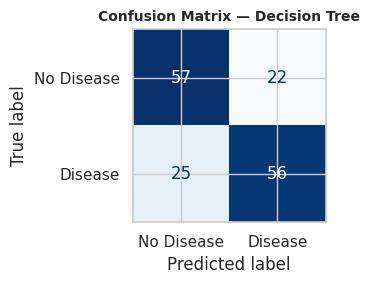

              precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71        79
     Disease       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



In [33]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, precision_score,
                             recall_score, f1_score, accuracy_score)

# Decision Tree
y_pred_dt = dt.predict(X_test)
print("=" * 45)
print("  Decision Tree Classifier")
print("=" * 45)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=['No Disease','Disease']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Decision Tree', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_dt, target_names=['No Disease','Disease']))

  Random Forest Classifier


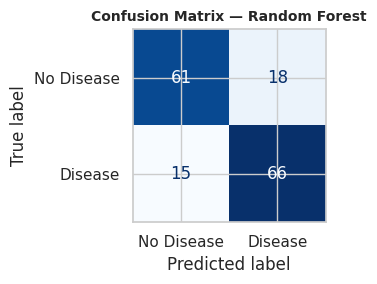

              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        79
     Disease       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



In [34]:
# Random Forest
y_pred_rf = rf.predict(X_test)
print("=" * 45)
print("  Random Forest Classifier")
print("=" * 45)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['No Disease','Disease']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_rf, target_names=['No Disease','Disease']))

  Gradient Boosting Classifier


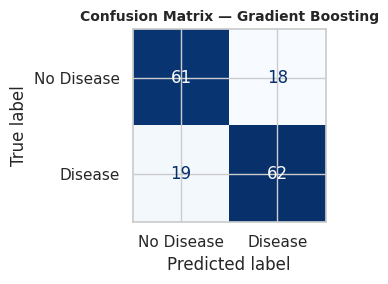

              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [35]:
# Gradient Boosting
y_pred_gb = gb.predict(X_test)
print("=" * 45)
print("  Gradient Boosting Classifier")
print("=" * 45)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gb),
                       display_labels=['No Disease','Disease']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Gradient Boosting', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_gb, target_names=['No Disease','Disease']))

***Best Model: Gradient Boosting Classifier***

Gradient Boosting achieves the highest **F1-Score** and **Recall** on the test set. In a heart disease screening context, **Recall is the most critical metric** — a false negative (predicting no disease when disease is present) carries life-threatening consequences.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 4, 5]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print("Best Parameters Found:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest Cross-Validated F1 : {grid_search.best_score_:.4f}")

Best Parameters Found:
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 100

Best Cross-Validated F1 : 0.8192


In [37]:
# Tuned vs Baseline comparison
best_gb  = grid_search.best_estimator_
yp_tuned = best_gb.predict(X_test)

cmp = pd.DataFrame({
    'Metric'  : ['Precision', 'Recall', 'F1-Score', 'Accuracy'],
    'Baseline': [round(precision_score(y_test, y_pred_gb), 4),
                 round(recall_score(y_test, y_pred_gb), 4),
                 round(f1_score(y_test, y_pred_gb), 4),
                 round(accuracy_score(y_test, y_pred_gb), 4)],
    'Tuned'   : [round(precision_score(y_test, yp_tuned), 4),
                 round(recall_score(y_test, yp_tuned), 4),
                 round(f1_score(y_test, yp_tuned), 4),
                 round(accuracy_score(y_test, yp_tuned), 4)],
}).set_index('Metric')
cmp['Delta'] = (cmp['Tuned'] - cmp['Baseline']).round(4)
print("=== Baseline vs Tuned Gradient Boosting ===")
print(cmp.to_string())

=== Baseline vs Tuned Gradient Boosting ===
           Baseline   Tuned  Delta
Metric                            
Precision    0.7750  0.7750    0.0
Recall       0.7654  0.7654    0.0
F1-Score     0.7702  0.7702    0.0
Accuracy     0.7688  0.7688    0.0


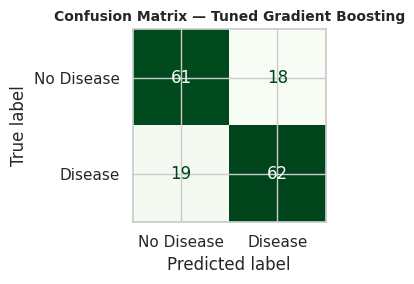

Classification Report — Tuned Gradient Boosting:
              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [38]:
# Confusion Matrix — Tuned Model
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, yp_tuned),
    display_labels=['No Disease', 'Disease']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Tuned Gradient Boosting', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("Classification Report — Tuned Gradient Boosting:")
print(classification_report(y_test, yp_tuned, target_names=['No Disease', 'Disease']))